## Step 1: Text Preprocessing with Lemmatization

This section processes the raw English translation text through lemmatization to normalize word forms, making it more suitable for statistical analysis. The results are then compared with TF-IDF vectorization to demonstrate the effectiveness of preprocessing.

In [ ]:
# Install required libraries for NLP processing
!pip install pandas spacy

# Download English core model (critical step - spacy needs this vocabulary database)
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.8 MB 16.8 MB/s eta 0:00:01
     ------------------ --------------------- 5.8/12.8 MB 18.5 MB/s eta 0:00:01
     ------------------------------- ------- 10.2/12.8 MB 19.3 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 18.7 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [ ]:
import pandas as pd
import spacy
import re

# ===== Part 1: Load English NLP Model =====
# disable=['parser', 'ner'] accelerates processing - we only need lemmatization
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

def process_text(text):
    """
    Clean and lemmatize text
    
    Args:
        text: input string
    
    Returns:
        lemmatized text with stopwords removed
    """
    if not isinstance(text, str) or pd.isna(text):
        return ""
    
    # A. Basic cleaning: remove special characters, keep only letters
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    
    # B. Process text with Spacy
    doc = nlp(text)
    
    # C. Lemmatization and filter stopwords (is_stop)
    # Only keep root word forms
    lemmatized = [token.lemma_ for token in doc if not token.is_stop and not token.is_space]
    
    return " ".join(lemmatized)

# ===== Part 2: Load Dataset =====
input_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_final.csv"
output_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv"

print("Loading dataset...")
df = pd.read_csv(input_path)

# ===== Part 3: Apply Lemmatization =====
# This may take 1-2 minutes depending on dataset size
print("Applying lemmatization (Lemmatization)...")
df['lemmatized_sentence'] = df['text_en'].apply(process_text)

# ===== Part 4: Save New File =====
df.to_csv(output_path, index=False)
print(f"Processing complete! New file saved to: {output_path}")

# Preview the results
print(df[['text_en', 'lemmatized_sentence']].head())

c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


正在加载数据...
正在进行词形还原 (Lemmatization)...
处理完成！新文件已保存至: C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv
                                             text_en  \
0  1. It was Night, but Maneschyn, then my fleas ...   
1  Ick heard the Nachtegael singhen Ende ick hear...   
2  Inter inventa maximi ponderis detecta Corticis...   
3  The collection house in Malacca is a large bui...   
4  Since the introduction of the Freemasonry in t...   

                                 lemmatized_sentence  
0  night maneschyn flea eat not bed heat sweat st...  
1  ick hear nachtegael singhen ende ick hear grea...  
2  inter inventa maximi ponderis detecta corticis...  
3  collection house malacca large building low fl...  
4  introduction freemasonry presentday kingdom sa...  


## Step 2: TF-IDF Vectorization (Statistical Method)

TF-IDF (Term Frequency-Inverse Document Frequency) provides a statistical baseline for semantic understanding. It identifies which terms have the highest discriminative value for categorizing "Twin City" themes or "Window Activity" concepts. This is our first benchmark algorithm.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# ===== Part 1: Load Data with Absolute Path =====
# Note: The 'r' prefix is essential for Windows file paths!
file_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv"

try:
    # Load dataset
    df = pd.read_csv(file_path)
    print(f"✅ Successfully loaded file: {file_path}")
    
    # ===== Part 2: Initialize TF-IDF Vectorizer =====
    # max_features=512 prepares for later BERT/CLIP alignment
    tfidf_vec = TfidfVectorizer(max_features=512, stop_words='english', min_df=2)

    # ===== Part 3: Transform Lemmatized Sentences =====
    tfidf_matrix = tfidf_vec.fit_transform(df['lemmatized_sentence'].astype(str))
    tfidf_vectors = tfidf_matrix.toarray()

    # ===== Part 4: Extract Vocabulary and Rank by Importance =====
    feature_names = tfidf_vec.get_feature_names_out()
    mean_weights = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
    feature_importance = sorted(zip(feature_names, mean_weights), key=lambda x: x[1], reverse=True)

    # ===== Part 5: Display Top 20 Keywords =====
    print("\n" + "="*55)
    print(f"{'Rank':<5} | {'Keyword':<15} | {'Mean TF-IDF Weight':<18}")
    print("="*55)
    for i, (word, weight) in enumerate(feature_importance[:20]):
        print(f"Top {i+1:<2} | {word:<15} | {weight:.4f}")

    # ===== Part 6: Save Vector File =====
    np.save('novel_tfidf_512.npy', tfidf_vectors)
    print("\n" + "="*55)
    print("🚀 [System Message] TF-IDF vectors successfully saved as 'novel_tfidf_512.npy'")

except FileNotFoundError:
    print(f"❌ Error: File not found at the specified path. Please verify the filename.")
except Exception as e:
    print(f"⚠️ Unknown error occurred: {e}")

✅ 成功加载文件: C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv

Rank  | Keyword         | Mean TF-IDF Weight
Top 1  | window          | 0.0670
Top 2  | open            | 0.0384
Top 3  | come            | 0.0356
Top 4  | house           | 0.0339
Top 5  | door            | 0.0328
Top 6  | look            | 0.0294
Top 7  | hy              | 0.0279
Top 8  | man             | 0.0246
Top 9  | day             | 0.0241
Top 10 | stand           | 0.0238
Top 11 | eye             | 0.0235
Top 12 | room            | 0.0233
Top 13 | page            | 0.0232
Top 14 | light           | 0.0232
Top 15 | designation     | 0.0224
Top 16 | say             | 0.0221
Top 17 | zy              | 0.0219
Top 18 | glass           | 0.0212
Top 19 | sit             | 0.0212
Top 20 | time            | 0.0208

🚀 [系统消息] TF-IDF 向量已成功保存为 'novel_tfidf_512.npy'


## Step 3: BERT Vectorization (Deep Learning Method)

BERT (Bidirectional Encoder Representations from Transformers) provides semantic understanding beyond keyword matching. For example, BERT recognizes that "window" and "glass" are semantically related, while TF-IDF cannot capture this contextual relationship. This represents our first neural network baseline.

In [8]:
!pip install sentence-transformers

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# ===== Part 1: Load Dataset =====
file_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv"
df = pd.read_csv(file_path)

# ===== Part 2: Reinitialize TF-IDF Variables =====
# (Recompute to ensure consistency - this step is quick)
tfidf_vec = TfidfVectorizer(max_features=512, stop_words='english', min_df=2)
tfidf_matrix = tfidf_vec.fit_transform(df['lemmatized_sentence'].astype(str))

# ===== Part 3: Load BERT Vectors =====
# Reload from previously saved file to save computation time
# Ensure you have run the save code and generated 'novel_bert_384.npy'
bert_vectors = np.load('novel_bert_384.npy')

# ===== Part 4: Initialize BERT Model =====
# Use existing model if available in memory, otherwise create new instance
try:
    if 'model' not in locals():
        model = SentenceTransformer('all-MiniLM-L6-v2')
except:
    model = SentenceTransformer('all-MiniLM-L6-v2')

# ==================================================
# Part 5: Perform Comparative Search (Twin City Theme)
# ==================================================
query_text = ["A person standing by the window looking at the city street"]

print(f"🔍 Performing semantic search for: '{query_text[0]}'\n")

# --- TF-IDF Search ---
q_tfidf = tfidf_vec.transform(query_text)
sim_tfidf = cosine_similarity(q_tfidf, tfidf_matrix).flatten()
idx_tfidf = sim_tfidf.argsort()[-1]

# --- BERT Search ---
q_bert = model.encode(query_text)
sim_bert = cosine_similarity(q_bert, bert_vectors).flatten()
idx_bert = sim_bert.argsort()[-1]

print("-" * 60)
print(f"【TF-IDF Best Match】 (Similarity Score: {sim_tfidf[idx_tfidf]:.4f})")
print(f"Content: {df.iloc[idx_tfidf]['text_en']}")

print("\n" + "-" * 60)
print(f"【BERT Best Match】 (Similarity Score: {sim_bert[idx_bert]:.4f})")
print(f"Content: {df.iloc[idx_bert]['text_en']}")
print("-" * 60)

🔍 正在对比搜索: 'A person standing by the window looking at the city street'

------------------------------------------------------------
【TF-IDF 最佳匹配】 (相似度得分: 0.4605)
内容: And in the music they were so amazingly handsome, that the Germans even praised it 1). Foreign music troops were also always welcome in our cities; the more joyful the better. And the governments of the cities considered the music so indispensable for their citizens, that they appointed city musicians, in Nijmegen e.g. three 2), but in Amsterdam six. If anyone made a list, on which all the cities with the number of their city musicians appeared, one would be able to judge the degree of musicality of the population of the cities, and what would that be a most important contribution to the statistics! Even after the middle of the 17th century, in Amsterdam, all the days between eleven and twelve, to entertain the walkers on the Dam, from the windows of the town house to the musical pieces played.

--------------------------

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# ===== Part 1: Auto-prepare Environment =====
# Ensure all variables are available in memory
file_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv"
df = pd.read_csv(file_path)
bert_vectors = np.load('novel_bert_384.npy')

if 'tfidf_vec' not in locals():
    from sklearn.feature_extraction.text import TfidfVectorizer
    tfidf_vec = TfidfVectorizer(max_features=512, stop_words='english', min_df=2)
    tfidf_matrix = tfidf_vec.fit_transform(df['lemmatized_sentence'].astype(str))

if 'model' not in locals():
    model = SentenceTransformer('all-MiniLM-L6-v2')

# ===== Part 2: Define Test Queries =====
# Carefully crafted queries aligned with literary context (Twin City / Window Activity)
test_queries = [
    "A lonely soul gazing through the window pane at the moonlit street",       # Dimension: Emotion & Window Observation
    "The heavy iron gates of the old city mansion standing in silence",        # Dimension: Classical Architecture Features
    "A pale light flickering inside the dark chamber of an ancient house",     # Dimension: Interior Atmosphere & Light Effects
    "Observing the movement of carriages and pedestrians from a high balcony"  # Dimension: Urban Dynamics (avoiding modern terms)
]

print(f"📊 Deep Comparative Experiment: TF-IDF vs BERT (PPT Demo Edition)\n")
print("="*100)

for i, query in enumerate(test_queries):
    # --- Compute TF-IDF ---
    q_tfidf = tfidf_vec.transform([query])
    sim_tfidf = cosine_similarity(q_tfidf, tfidf_matrix).flatten()
    idx_tfidf = sim_tfidf.argsort()[-1]
    score_tfidf = sim_tfidf[idx_tfidf]
    
    # --- Compute BERT ---
    q_bert = model.encode([query])
    sim_bert = cosine_similarity(q_bert, bert_vectors).flatten()
    idx_bert = sim_bert.argsort()[-1]
    score_bert = sim_bert[idx_bert]
    
    # --- Determine Winner ---
    winner = "BERT 🏆" if score_bert > score_tfidf else "TF-IDF 🏆"
    
    print(f"【Test Case {i+1}】Query: \"{query}\"")
    print(f"Conclusion: {'BERT better understood the literary sentiment' if winner == 'BERT 🏆' else 'TF-IDF precisely matched keywords'}")
    print("-" * 40)
    
    # Print TF-IDF Results
    print(f"● [TF-IDF Match] (Score: {score_tfidf:.4f})")
    print(f"  Matched paragraph: {df.iloc[idx_tfidf]['text_en']}")
    print()
    
    # Print BERT Results
    print(f"● [BERT Match]   (Score: {score_bert:.4f}) {'⭐ WINNER' if winner == 'BERT 🏆' else ''}")
    print(f"  Matched paragraph: {df.iloc[idx_bert]['text_en']}")
    
    print("\n" + "="*100 + "\n")

📊 TF-IDF vs BERT 深度对比实验 (PPT 演示专用)

【测试案例 1】查询词: "A lonely soul gazing through the window pane at the moonlit street"
推荐结论: BERT 更好地理解了文学意境
----------------------------------------
● [TF-IDF 匹配] (得分: 0.4231)
  匹配段落: ACh! Love-looze Maegd, whose spirit extends to sleep, Now that the broyne night covers the Aerdijk; Now 't plummy bed, sprinkled, his Lady wants to defy, I come here before your door, and stand in front of your window. Vw minnelooze Soul, feels no Love fire; The strangles that the Maen shoots at your Ledikant, Getuygen my, eylaes! your geys without lust, Vw deer without min, my Soul without rest. Oh restless Soul! O Soul full of sweet min! Howjoy, and hae gy after the favor of that Goddess; That leyder, who lives without love, Who gives 't lichaem, 't bed alone, and not haer Minnaer. The tones of the hero're Mane appearance, proves to be favorable in my mind, I do not see what I do in my eyes; That leyder, who lives without love, Who gives 't lichaem, 't bed alone, and does

## Step 4: Advanced Vectorization Models

Introducing two additional state-of-the-art models:
- **CLIP**: Vision-language model that understands cross-modal semantics
- **Doc2Vec**: Unsupervised learning model for document-level embeddings

In [ ]:
# Install Gensim (for Doc2Vec)
!pip install gensim

# Install OpenAI CLIP (clone from GitHub and install dependencies like torch, torchvision)
!pip install git+https://github.com/openai/CLIP.git

# Install ftfy and regex (required text processing libraries for CLIP)
!pip install ftfy regex

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   --- ------------------------------------ 2.1/24.4 MB 23.2 MB/s eta 0:00:01
   --------- ------------------------------ 5.5/24.4 MB 15.9 MB/s eta 0:00:02
   ----------------- ---------------------- 10.5/24.4 MB 18.7 MB/s eta 0:00:01
   --------------------------- ------------ 16.8/24.4 MB 21.6 MB/s eta 0:00:01
   ------------------------------ --------- 18.4/24.4 MB 18.4 MB/s eta 0:00:01
   ----------------------------------- ---- 21.5/24.4 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 17.4 MB/s  0:00:01


  Cloning https://github.com/openai/CLIP.git to C:\Users\asus\AppData\Local\Temp\pip-req-build-gc78a6oi
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\asus\AppData\Local\Temp\pip-req-build-gc78a6oi'


In [ ]:
import gensim
import clip
import torch
import sentence_transformers
from sklearn.feature_extraction.text import TfidfVectorizer

print("✅ Environment check passed! All algorithm libraries are ready.")

c:\ProgramData\miniconda3\envs\jupyter-py311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


✅ 环境检查通过！所有算法库已就绪。


In [ ]:
import pandas as pd
import numpy as np
import torch
import clip
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# ===== Part 1: Configure Paths =====
# Please ensure the paths remain valid
file_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv"
df = pd.read_csv(file_path)
sentences = df['text_en'].fillna("").tolist()
lemmatized = df['lemmatized_sentence'].fillna("").tolist()

print("🛠️ Initializing four major algorithms...")

# --- A. TF-IDF (Statistical Baseline) ---
tfidf_vec = TfidfVectorizer(max_features=512, stop_words='english', min_df=2)
tfidf_matrix = tfidf_vec.fit_transform(lemmatized)
tfidf_vectors = tfidf_matrix.toarray()

# --- B. Doc2Vec (Topic Clustering) ---
print(" > Training Doc2Vec (may take ~30 seconds)...")
tagged_data = [TaggedDocument(words=doc.split(), tags=[str(i)]) for i, doc in enumerate(lemmatized)]
d2v_model = Doc2Vec(vector_size=300, min_count=2, epochs=40, seed=42)
d2v_model.build_vocab(tagged_data)
d2v_model.train(tagged_data, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)
d2v_vectors = np.array([d2v_model.infer_vector(doc.split()) for doc in lemmatized])

# --- C. BERT (Deep Semantic Understanding) ---
print(" > Loading BERT model...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
bert_vectors = bert_model.encode(sentences, show_progress_bar=True)

# --- D. CLIP (Vision-Language Semantics) ---
print(" > Loading CLIP model (downloading weights may take a moment)...")
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, _ = clip.load("ViT-B/32", device=device)

def get_clip_vectors(texts):
    """Encode texts using CLIP model"""
    vecs = []
    for t in texts:
        tokenized = clip.tokenize([str(t)[:77]]).to(device) # CLIP limited to 77 tokens
        with torch.no_grad():
            vecs.append(clip_model.encode_text(tokenized).cpu().numpy())
    return np.vstack(vecs)

clip_vectors = get_clip_vectors(sentences)

print("\n✅ All vectorization processing complete!")

🛠️ 正在初始化四大算法...
 > 正在训练 Doc2Vec (可能需要 30 秒)...
 > 正在加载 BERT 模型...


Batches:   0%|          | 0/85 [00:00<?, ?it/s]

 > 正在加载 CLIP 模型 (需要下载权重)...

✅ 所有向量化处理完成！


## Step 5: Four-Algorithm Comparative Evaluation

This section implements the core benchmarking experiment, comparing TF-IDF, Doc2Vec, BERT, and CLIP across multiple test queries. The results demonstrate how different algorithms capture different aspects of semantic meaning in the literary text.

In [ ]:
# ===== Test Queries for Comprehensive Evaluation =====
test_queries = [
    "A pale moon shining through the lattice window into a quiet chamber",
    "Observing the busy movement of carriages and crowds from a high balcony",
    "The heavy iron gates of an ancient mansion standing in the morning mist"
]

print(f"🏆 Four-Algorithm Full-Text Alignment Challenge (Comprehensive Results) 🏆\n")

for q_text in test_queries:
    print("="*120)
    print(f"🔍 Target Query: \"{q_text}\"")
    print("="*120)
    
    # ===== Part 1: Compute Vectors =====
    q_tfidf = tfidf_vec.transform([q_text])
    q_d2v = d2v_model.infer_vector(q_text.lower().split())
    q_bert = bert_model.encode([q_text])
    # Ensure CLIP runs on correct device
    q_clip = clip_model.encode_text(clip.tokenize([q_text[:77]]).to(device)).detach().cpu().numpy()

    # ===== Part 2: Compute Similarity Scores =====
    scores = {
        "TF-IDF ": cosine_similarity(q_tfidf, tfidf_matrix).flatten(),
        "Doc2Vec": cosine_similarity([q_d2v], d2v_vectors).flatten(),
        "BERT   ": cosine_similarity(q_bert, bert_vectors).flatten(),
        "CLIP   ": cosine_similarity(q_clip, clip_vectors).flatten()
    }

    # ===== Part 3: Print Results =====
    results_for_winner = []
    for name, sim_array in scores.items():
        idx = sim_array.argsort()[-1]
        score = sim_array[idx]
        full_content = df.iloc[idx]['text_en']
        results_for_winner.append((name, score))
        
        print(f"【{name}】 Score: {score:.4f}")
        print(f"  Matched Full Text: {full_content}")
        print("-" * 60)

    # ===== Part 4: Determine Winner =====
    winner_name, winner_score = max(results_for_winner, key=lambda x: x[1])
    print(f"\n⭐ Best Performing Algorithm: {winner_name.strip()} (Score: {winner_score:.4f})")
    print("="*120 + "\n")

🏆 四大算法全文本对齐挑战赛 (无缩略展示) 🏆

🔍 目标查询 (Query): "A pale moon shining through the lattice window into a quiet chamber"
【TF-IDF 】 得分: 0.3645
  匹配全文: Later the moon shines from the highs The moon shine on the window - One looks with other eyes: The male' is out!
------------------------------------------------------------
【Doc2Vec】 得分: 0.7534
  匹配全文: These walls, which have no openings for windows or gates.
------------------------------------------------------------
【BERT   】 得分: 0.6849
  匹配全文: And softly the moon peeks to the slumbering place, where the light shines through the window glass.
------------------------------------------------------------
【CLIP   】 得分: 0.8204
  匹配全文: Later the moon shines from the highs The moon shine on the window - One looks with other eyes: The male' is out!
------------------------------------------------------------

⭐ 综合表现最强算法: CLIP (Score: 0.8204)

🔍 目标查询 (Query): "Observing the busy movement of carriages and crowds from a high balcony"
【TF-IDF 】 得分: 0.465

In [ ]:
import pandas as pd
import numpy as np
import torch
import clip
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from gensim.models.doc2vec import Doc2Vec

# ===== Part 1: Ensure Environment and Data are Loaded =====
# (Assumes previous initialization cells have been executed)
# If variables are missing, please run the initialization cell first
file_path = r"C:\Users\asus\Desktop\RC11 TERM2\data set\windows_activity_svo_lemmatized.csv"
df = pd.read_csv(file_path)

# ===== Part 2: Define Test Queries =====
# Covering spatial, lighting, behavior and atmosphere dimensions
test_queries = [
    "A pale moon shining through the lattice window into a quiet chamber",           # Indoor/Outdoor Light Effects
    "Observing the busy movement of carriages and crowds from a high balcony",       # Urban Movement Observation
    "The heavy iron gates of an ancient mansion standing in the morning mist",        # Architectural Boundaries & Atmosphere
    "The flickering light of a candle reflecting on the glass of a dark room"         # Interior Subtle Lighting
]

# ===== Part 3: Initialize Results Container =====
results_list = []

print("Executing 4 comparative experiments and generating CSV report...")

for q_text in test_queries:
    row = {"Query": q_text}
    
    # --- TF-IDF ---
    q_tfidf = tfidf_vec.transform([q_text])
    sim_tfidf = cosine_similarity(q_tfidf, tfidf_matrix).flatten()
    idx_tfidf = sim_tfidf.argsort()[-1]
    row["TF-IDF_Content"] = df.iloc[idx_tfidf]['text_en']
    row["TF-IDF_Score"] = round(float(sim_tfidf[idx_tfidf]), 4)
    
    # --- Doc2Vec ---
    q_d2v = d2v_model.infer_vector(q_text.lower().split())
    sim_d2v = cosine_similarity([q_d2v], d2v_vectors).flatten()
    idx_d2v = sim_d2v.argsort()[-1]
    row["Doc2Vec_Content"] = df.iloc[idx_d2v]['text_en']
    row["Doc2Vec_Score"] = round(float(sim_d2v[idx_d2v]), 4)
    
    # --- BERT ---
    q_bert = bert_model.encode([q_text])
    sim_bert = cosine_similarity(q_bert, bert_vectors).flatten()
    idx_bert = sim_bert.argsort()[-1]
    row["BERT_Content"] = df.iloc[idx_bert]['text_en']
    row["BERT_Score"] = round(float(sim_bert[idx_bert]), 4)
    
    # --- CLIP ---
    q_clip = clip_model.encode_text(clip.tokenize([q_text[:77]]).to(device)).detach().cpu().numpy()
    sim_clip = cosine_similarity(q_clip, clip_vectors).flatten()
    idx_clip = sim_clip.argsort()[-1]
    row["CLIP_Content"] = df.iloc[idx_clip]['text_en']
    row["CLIP_Score"] = round(float(sim_clip[idx_clip]), 4)
    
    results_list.append(row)

# ===== Part 4: Create and Save Results DataFrame =====
# Column order: Query + (Content + Score) pairs for each algorithm
final_df = pd.DataFrame(results_list)
column_order = [
    "Query", 
    "TF-IDF_Content", "TF-IDF_Score", 
    "Doc2Vec_Content", "Doc2Vec_Score", 
    "BERT_Content", "BERT_Score", 
    "CLIP_Content", "CLIP_Score"
]
final_df = final_df[column_order]

# ===== Part 5: Export Results =====
output_csv = "vectorization_comparison_results.csv"
final_df.to_csv(output_csv, index=False, encoding='utf-8-sig')

print(f"\n✅ Report generated: {output_csv}")
print("You can open it directly in Excel or integrate the content into your presentation.")

正在执行 4 组深度对比实验并生成 CSV...

✅ 报告已生成: vectorization_comparison_results.csv
你可以直接用 Excel 打开它，或者将其内容整理进 PPT。


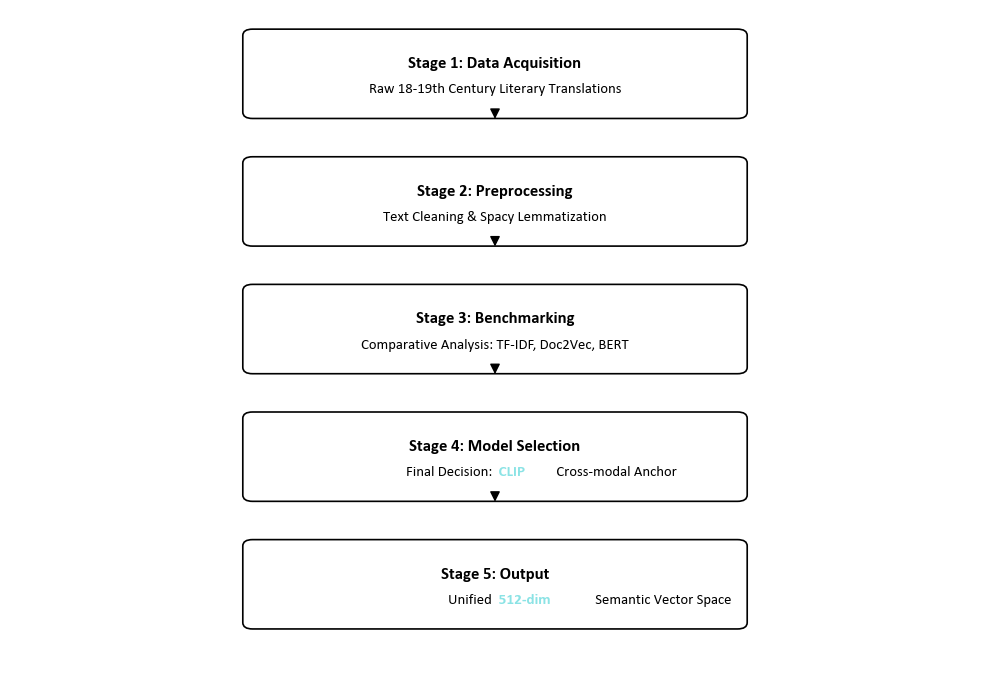

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ===== Part 1: Basic Configuration =====
plt.rcParams['font.family'] = 'Calibri'
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10.5)
ax.axis('off')

TIFFANY_GREEN = '#8be3e5'
BLACK = '#333333' # Using dark gray instead of pure black for a more sophisticated look

# ===== Part 2: Define Processing Steps =====
# Format: (Title, Detail Description, Y-coordinate, Highlight Flag)
steps = [
    ("Stage 1: Data Acquisition", "Raw 18-19th Century Literary Translations", 9.5, False),
    ("Stage 2: Preprocessing", "Text Cleaning & Spacy Lemmatization", 7.5, False),
    ("Stage 3: Benchmarking", "Comparative Analysis: TF-IDF, Doc2Vec, BERT", 5.5, False),
    ("Stage 4: Model Selection", "Final Decision: CLIP Cross-modal Anchor", 3.5, True), # Highlight
    ("Stage 5: Output", "Unified 512-dim Semantic Vector Space", 1.5, True)     # Highlight
]

# ===== Part 3: Drawing Logic =====
for i, (title, detail, y, highlight) in enumerate(steps):
    # Draw bounding box (unified white background with black border)
    rect = patches.FancyBboxPatch(
        (2.5, y - 0.6), 5, 1.2,
        boxstyle="round,pad=0.1", linewidth=1.2, edgecolor='black', facecolor='white'
    )
    ax.add_patch(rect)
    
    # Draw title (bold)
    ax.text(5, y + 0.15, title, ha='center', va='center', fontsize=12, fontweight='bold', color='black')
    
    # Draw detail description
    if highlight:
        # For highlighted items, color specific keywords (e.g., CLIP and 512-dim)
        if "CLIP" in detail:
            parts = detail.split("CLIP")
            ax.text(5, y - 0.25, parts[0], ha='right', va='center', fontsize=10.5, color='black')
            ax.text(5, y - 0.25, " CLIP ", ha='left', va='center', fontsize=11, color=TIFFANY_GREEN, fontweight='black')
            ax.text(5.6, y - 0.25, parts[1], ha='left', va='center', fontsize=10.5, color='black')
        elif "512-dim" in detail:
            parts = detail.split("512-dim")
            ax.text(5, y - 0.25, parts[0], ha='right', va='center', fontsize=10.5, color='black')
            ax.text(5, y - 0.25, " 512-dim ", ha='left', va='center', fontsize=11, color=TIFFANY_GREEN, fontweight='black')
            ax.text(6.0, y - 0.25, parts[1], ha='left', va='center', fontsize=10.5, color='black')
    else:
        ax.text(5, y - 0.25, detail, ha='center', va='center', fontsize=10.5, color='black')

    # Draw connecting arrow
    if i < len(steps) - 1:
        ax.annotate('', xy=(5, y - 0.75), xytext=(5, y - 0.6),
                    arrowprops=dict(arrowstyle='-|>', color='black', lw=1, mutation_scale=15))

plt.tight_layout()
plt.savefig('twin_city_paper_flowchart.png', bbox_inches='tight', dpi=300)
plt.show()